In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

from scipy.special import sici
from scipy.integrate import quad

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [28]:

odir = "../../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [146]:

with open(f"{odir}/snap40/mvir/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: '../../ps_data/snap40/mvir//number_density/ps-intensity-group_logM10.pickle'

In [147]:

odir = "../../ps_data/snap40/mvir//number_density"
with open(f"{odir}/gal/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10_1 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [148]:

with open(f"{odir}/group/ps-intensity-group_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10_1 = pickle.load(f)

In [26]:

odir = "../../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sat_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sat10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 1301.8023048542211


In [132]:

with open(f"{odir}/ps-intensity-sat_sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sat_sum10 = pickle.load(f)

In [133]:

odir = "../../ps_data/snap40/mvir"
with open(f"{odir}/number_density/sat/ps-intensity-sat_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sat10_1 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [128]:

with open(f"{odir}/number_density/sat_sum/ps-intensity-sat_sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sat_sum10_1 = pickle.load(f)

In [121]:

odir = "../../ps_data/snap40/mvir/logMmin"
with open(f"{odir}/sat/number_density/logM11.0.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sat11 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [119]:

odir = "../../ps_data/snap40/mvir/logMmin"
with open(f"{odir}/sat_sum/number_density/logM11.0.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sat_sum11 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [11]:
logks_tng = np.log10(Pk_sum10["k"])

In [12]:
def compute_uk2(Pk_gal10, Pk_sum10):
    ks_tng = Pk_gal10["k"]


    tot = (Pk_gal10["power"]-(Pk_sum10["power"]-Pk_sum10.attrs["shotnoise"]))
    
    shot_gal = Pk_gal10.attrs["shotnoise"]
    shot_halo = Pk_sum10.attrs["shotnoise"]
    uk2 = (tot - shot_gal)/(shot_halo - shot_gal)
    return uk2

In [30]:
uk2_13 = compute_uk2(Pk_gal10, Pk_sum10)
uk2_1 = compute_uk2(Pk_sat10, Pk_sat_sum10)

In [141]:
uk2_gal1 = compute_uk2(Pk_gal10_1, Pk_sum10_1)

In [137]:
uk2_2 = compute_uk2(Pk_sat10_1, Pk_sat_sum10_1)

In [122]:
uk2_11 = compute_uk2(Pk_sat11, Pk_sat_sum11)

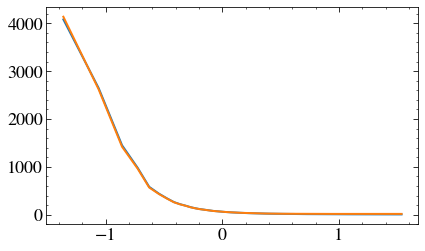

In [149]:
plt.plot(logks_tng, Pk_gal10_1["power"].real)
plt.plot(logks_tng, Pk_sum10_1["power"].real)

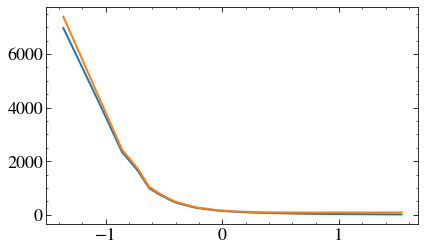

In [138]:
plt.plot(logks_tng, Pk_sat10_1["power"].real)
plt.plot(logks_tng, Pk_sat_sum10_1["power"].real)

In [31]:
def nfw_profile(r, rho0, rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

def rho_s(mvir, r_s, c):
    rhos = (mvir/(4*np.pi*r_s**3))*(np.log(1+c) - c/(1+c))**-1
    return rhos

In [32]:
def nfw_ft_numerical(k_values, rho0, rs, rvir, rmax):

    def integrand_func(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs) * np.sin(k * r) / (k * r)
        return integrand

    def integrand_norm(r):
        integrand = 4*np.pi* r**2 * nfw_profile(r, rho0, rs)
        return integrand

    norm_factor = quad(integrand_norm , 0, rmax)[0]
    results = []
    for k in k_values:
        result = quad(integrand_func , 0, rmax)[0]
        results.append(result)

    return np.array(results)/norm_factor

In [163]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
c=20
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk_numerical = nfw_ft_numerical(ks, rho0, rs,rvir, rmax=1)

In [153]:
logks = np.arange(-1.5,2,0.01)
ks = 10**logks
c=80
rvir=0.5
rs = rvir/c
rho0 = rho_s(10**13, rs, c)
uk_numerical2 = nfw_ft_numerical(ks, rho0, rs,rvir, rmax=1)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


(-1.55, 1.3)

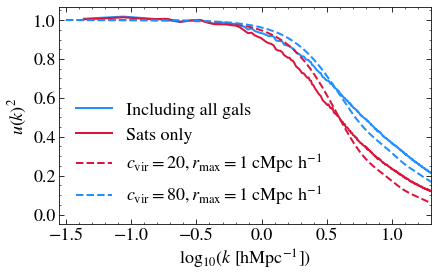

In [167]:

plt.plot(logks_tng, uk2_13, label="Including all gals",c="DodgerBlue")

#plt.plot(logks_tng, uk2_gal1, label="Unweighted $u_{\mathrm{sat}}(k)^2$",c="DodgerBlue")
plt.plot(logks_tng, uk2_1, label="Sats only",c="Crimson")
#plt.plot(logks_tng, uk2_2, label="SFR-weighted $u_{\mathrm{sat}}(k)^2$",c="Crimson")


#plt.plot(logks_tng, uk2_11, label="SFR-weighted $u_{\mathrm{sat}}(k)^2$",c="orange")


plt.plot(logks, uk_numerical**2, label="$c_{\mathrm{vir}}=20, r_{\mathrm{max}}=$1 cMpc $\mathrm{h^{-1}}$", linestyle="dashed",c="Crimson")
plt.plot(logks, uk_numerical2**2, label="$c_{\mathrm{vir}}=80, r_{\mathrm{max}}=$1 cMpc $\mathrm{h^{-1}}$", linestyle="dashed",c="DodgerBlue")


plt.legend()

plt.xlabel(r"$\mathrm{log}_{10}(k\ \mathrm{[h Mpc^{-1}]})$")
plt.ylabel("$u(k)^2$")
plt.xlim(-1.55,1.3)

# ax = plt.gca()
# ax.annotate(f"logM13-13.1", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

#plt.savefig("../figures/u_k_logM13.pdf", format="pdf", bbox_inches="tight")